# 02 — Data Preprocessing (WISDM Dataset)
**Goal:** Load the raw WISDM and M5-Watch data to compare and visualize range of values after z-score normalization, mapping activity labels, and preparing the data for training.

### The WISDM Dataset
This dataset contains data from 51 subjects wearing a smartwatch and a smartphone.
We will specifically use the **Smartwatch** data (Accelerometer + Gyroscope) to match our M5StickC use-case.

We will filter the 18 original activities down to the 6 we care about:
- Walking (`A`)
- Standing (`E`)
- Typing (`F`)
- Sitting (`D`)
- Eating (`H`, `I`, `J`, `L`)
- Writing (`Q`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import urllib.request
import os

# --- 1. Download & Extract Dataset (Run Once) ---
data_dir = Path('../dataset/wisdm')
data_dir.mkdir(parents=True, exist_ok=True)
zip_path = data_dir / 'wisdm-dataset.zip'

if not zip_path.exists():
    print("Downloading WISDM dataset (295 MB) - this may take a minute...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00507/wisdm-dataset.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Done!")
else:
    print("WISDM dataset already downloaded and extracted.")

base_path = data_dir / 'wisdm-dataset' / 'raw'
accel_path = base_path / 'watch' / 'accel'
gyro_path = base_path / 'watch' / 'gyro'

WISDM dataset already downloaded and extracted.


### Load & Merge Accelerometer and Gyroscope Data
The WISDM dataset stores accelerometer and gyroscope files separately for each of the 51 subjects.
We will read them, merge them based on timestamps, and map the activity labels.

In [2]:
# --- 2. Define Activity Mapping ---
activity_map = {
    'A': 'Walking',
    'E': 'Standing',
    'F': 'Typing',
    'D': 'Sitting',
    'H': 'Eating',   # Eating Soup
    'I': 'Eating',   # Eating Chips
    'J': 'Eating',   # Eating Pasta
    'L': 'Eating',   # Eating Sandwich
    'Q': 'Writing'
}

def load_sensor_data(folder_path, sensor_type):
    print(f"Loading {sensor_type} data from {folder_path}...")
    dfs = []
    
    # Read all 51 txt files
    for file_path in sorted(folder_path.glob('*.txt')):
        # The raw text files have trailing semicolons, we need to clean that
        df = pd.read_csv(file_path, header=None, 
                         names=['subject_id', 'activity_code', 'timestamp', 'x', 'y', 'z'])
        
        # Clean the 'z' column (remove trailing semicolon and cast to float), this is present in the original .txt Wisdm dataset..
        df['z'] = df['z'].astype(str).str.replace(';', '', regex=False).astype(float)
        
        # Keep only the activities we care about..
        df = df[df['activity_code'].isin(activity_map.keys())].copy()
        df['activity'] = df['activity_code'].map(activity_map)
        
        # Rename axes to match sensor
        df = df.rename(columns={'x': f'{sensor_type}_x', 
                                'y': f'{sensor_type}_y', 
                                'z': f'{sensor_type}_z'})
        dfs.append(df)
        
    return pd.concat(dfs, ignore_index=True)

# Load Accel and Gyro
if accel_path.exists() and gyro_path.exists():
    df_accel = load_sensor_data(accel_path, 'acc')
    df_gyro = load_sensor_data(gyro_path, 'gyro')
    
    # Merge on subject, activity, and approximate timestamp
    # (In WISDM, accel and gyro timestamps aren't perfectly synced to the millisecond,
    # but they are recorded simultaneously at 20Hz. For a perfect merge, we sort and merge_asof)
    print("\nMerging Accelerometer and Gyroscope data...")
    df_accel = df_accel.sort_values('timestamp')
    df_gyro = df_gyro.sort_values('timestamp')
    
    df_wisdm = pd.merge_asof(df_accel, 
                             df_gyro[['subject_id', 'activity_code', 'timestamp', 'gyro_x', 'gyro_y', 'gyro_z']], 
                             on='timestamp', 
                             by=['subject_id', 'activity_code'], 
                             direction='nearest', 
                             tolerance=50000000) # 50ms tolerance in nanoseconds
    
    df_wisdm = df_wisdm.dropna() # Drop rows where no gyro match was found
    
    # Display the breakdown
    print("\n=== Final Dataset Activity Count ===")
    activity_counts = df_wisdm['activity'].value_counts().to_frame(name='Samples')
    activity_counts['Minutes'] = (activity_counts['Samples'] / 20 / 60).round(2)
    print(activity_counts)
    
    display(df_wisdm.head())
else:
    print(f"Could not find paths. Check if {base_path} exists.")

Loading acc data from ..\dataset\wisdm\wisdm-dataset\raw\watch\accel...
Loading gyro data from ..\dataset\wisdm\wisdm-dataset\raw\watch\gyro...

Merging Accelerometer and Gyroscope data...

=== Final Dataset Activity Count ===
          Samples  Minutes
Eating     817340   681.12
Writing    215346   179.46
Sitting    212980   177.48
Walking    210476   175.40
Standing   207582   172.98
Typing     205120   170.93


,subject_id,activity_code,timestamp,acc_x,acc_y,acc_z,activity,gyro_x,gyro_y,gyro_z
0,1632,J,2401041020041,-3.019687,-4.071938,8.012345,Eating,0.233643,-0.066053,-0.096306
1,1632,J,2401090520041,-3.831321,-5.340866,6.832004,Eating,0.233643,-0.066053,-0.096306
2,1632,J,2401140020041,-2.746748,-5.309741,7.727436,Eating,0.307147,0.044734,-0.206029
3,1632,J,2401189520041,-2.595913,-6.418256,7.928548,Eating,0.081311,0.090541,-0.234791
4,1632,J,2401239020041,-2.253542,-5.987300,8.321198,Eating,-0.498193,0.271635,-0.274205


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Adjust this path if necessary to point to the M5StickC data..
data_dir = Path("..") / "dataset" / "data_M5stickC"

dfs = []
for f in sorted(data_dir.glob("*.csv")):
    df = pd.read_csv(f)
    
    # Skip files that don't have the g_scale column
    if "g_scale" not in df.columns:
        print(f"Skipping this CSV from analysis: {f.name} — no g_scale column (old file)")
        continue
    
    # Check if 'activity' column exists
    if "activity" not in df.columns:
        print(f"Skipping this CSV from analysis: {f.name} — no activity column")
        continue

    # Filter strictly for 'Eating' activity
    # Note: Make sure the capitalization matches how it's stored in your CSV 
    # (e.g., 'Eating', 'eating', or 'EATING')
    df_eating = df[df["activity"] == "Eating"].copy()
    
    # Only append if there are actually Eating samples in this file
    if df_eating.empty:
        print(f"Skipping {f.name} — no 'Eating' samples found.")
        continue
        
    df_eating["source_file"] = f.name
    dfs.append(df_eating)
    print(f"Loaded {f.name} → {len(df_eating)} 'Eating' samples | g_scales: {df_eating['g_scale'].unique()}")

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal 'Eating' samples: {len(df_all)}")
    print("All g_scales found:", sorted(df_all["g_scale"].unique()))
    print("Activities:", df_all["activity"].unique())
else:
    print("\nNo 'Eating' samples found in any valid CSV file.")

Skipping this CSV from analysis: m5stick_20260406_104709.csv — no g_scale column (old file)
Skipping this CSV from analysis: m5stick_20260406_124221.csv — no g_scale column (old file)
Skipping this CSV from analysis: m5stick_20260406_124443.csv — no g_scale column (old file)
Skipping this CSV from analysis: m5stick_20260410_154653.csv — no g_scale column (old file)
Skipping this CSV from analysis: m5stick_20260413_133051.csv — no g_scale column (old file)
Loaded m5stick_2_4_g_500dps.csv → 1106 'Eating' samples | g_scales: ['AFS_2G' 'AFS_4G' 'AFS_8G']
Loaded m5stick_8_16_g_500dps.csv → 905 'Eating' samples | g_scales: ['AFS_8G' 'AFS_16G']
Skipping this CSV from analysis: m5stick_data_20250709_171243.csv — no g_scale column (old file)

Total 'Eating' samples: 2011
All g_scales found: ['AFS_16G', 'AFS_2G', 'AFS_4G', 'AFS_8G']
Activities: ['Eating']


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# ==========================================
# 1. M5StickC Data
# ==========================================
if 'df_all' not in globals():
    raise ValueError("df_all not found! Please run the M5 loading loop first.")

N_SAMPLES = 200
START_IDX = 500  # Skipping intial 25 seconds to reach steady state of activity motion..

def process_slice(df_subset, source_name):
    """Extracts a slice, handles dynamic column names, and applies Z-scoring."""
    
    # 1. Detect your specific accelerometer columns by looking for variations of X, Y, Z
    cols = df_subset.columns.str.lower()
    
    # usual names for X: 'x', 'ax', 'acc_x', 'accel_x', 'accelx', etc. to understand column names dynamically.. (but recheck if you run into naming problems)
    x_col = next((c for c in df_subset.columns if c.lower() in ['x', 'ax', 'acc_x', 'accel_x', 'accelx', 'accX']), None)
    y_col = next((c for c in df_subset.columns if c.lower() in ['y', 'ay', 'acc_y', 'accel_y', 'accely', 'accY']), None)
    z_col = next((c for c in df_subset.columns if c.lower() in ['z', 'az', 'acc_z', 'accel_z', 'accelz', 'accZ']), None)
    
    if not all([x_col, y_col, z_col]):
        raise KeyError(f"Could not find Accelerometer X, Y, Z columns in {source_name}. Available columns: {list(df_subset.columns)}")
        
    # Renaming them uniformly to accel_x, accel_y, accel_z.. to match wisdm dataset..
    df_subset = df_subset.rename(columns={x_col: 'accel_x', y_col: 'accel_y', z_col: 'accel_z'})
    accel_cols = ['accel_x', 'accel_y', 'accel_z']
    
    # 2. Extract Slice safely
    if len(df_subset) < START_IDX + N_SAMPLES:
        print(f"Warning: {source_name} has only {len(df_subset)} samples (needs {START_IDX + N_SAMPLES}). Taking last {N_SAMPLES} samples.")
        if len(df_subset) < N_SAMPLES:
            slice_df = df_subset[accel_cols].copy() # Take whatever is there if it's super short
        else:
            slice_df = df_subset[accel_cols].tail(N_SAMPLES).copy()
    else:
        slice_df = df_subset[accel_cols].iloc[START_IDX:START_IDX + N_SAMPLES].copy()
    
    # 3. Applying Z-score standardization to each axis..
    for col in accel_cols:
        # Check if std is 0 to avoid division by zero errors returning NaNs..
        if slice_df[col].std() == 0:
            slice_df[f'{col}_z'] = 0 
        else:
            slice_df[f'{col}_z'] = zscore(slice_df[col])
        
    slice_df['source'] = source_name
    slice_df['sample_idx'] = range(len(slice_df))
    return slice_df
processed_dfs = []

# Loop through each unique G-scale found in the loaded M5 data..
for g_val in sorted(df_all["g_scale"].unique()):
    # Get all rows for this specific g-scale
    df_g = df_all[df_all["g_scale"] == g_val]
    source_label = f"M5StickC ({g_val}g)"
    
    processed_dfs.append(process_slice(df_g, source_label))

In [10]:
# ==========================================
# 2. WISDM Data
# ==========================================
# We use label 3 (Eating)..
if 'df_wisdm' in globals():
    # Filter for 'Eating' using string 'activity' column..
    df_wisdm_eating = df_wisdm[df_wisdm['activity'] == 'Eating'].copy()
    
    # Rename acc_x to accel_x so the plotting function understands it..
    df_wisdm_eating = df_wisdm_eating.rename(columns={
        'acc_x': 'accel_x', 
        'acc_y': 'accel_y', 
        'acc_z': 'accel_z'
    })
    
    if not df_wisdm_eating.empty:
        processed_dfs.append(process_slice(df_wisdm_eating, 'WISDM (Standard)'))
    else:
        print("Warning: No 'Eating' data found in WISDM dataset.")
else:
    print("Warning: df_wisdm not found in memory. Run your WISDM loading cell first.")

# Combine all cases into one DataFrame for plotting..
df_plot = pd.concat(processed_dfs, ignore_index=True)

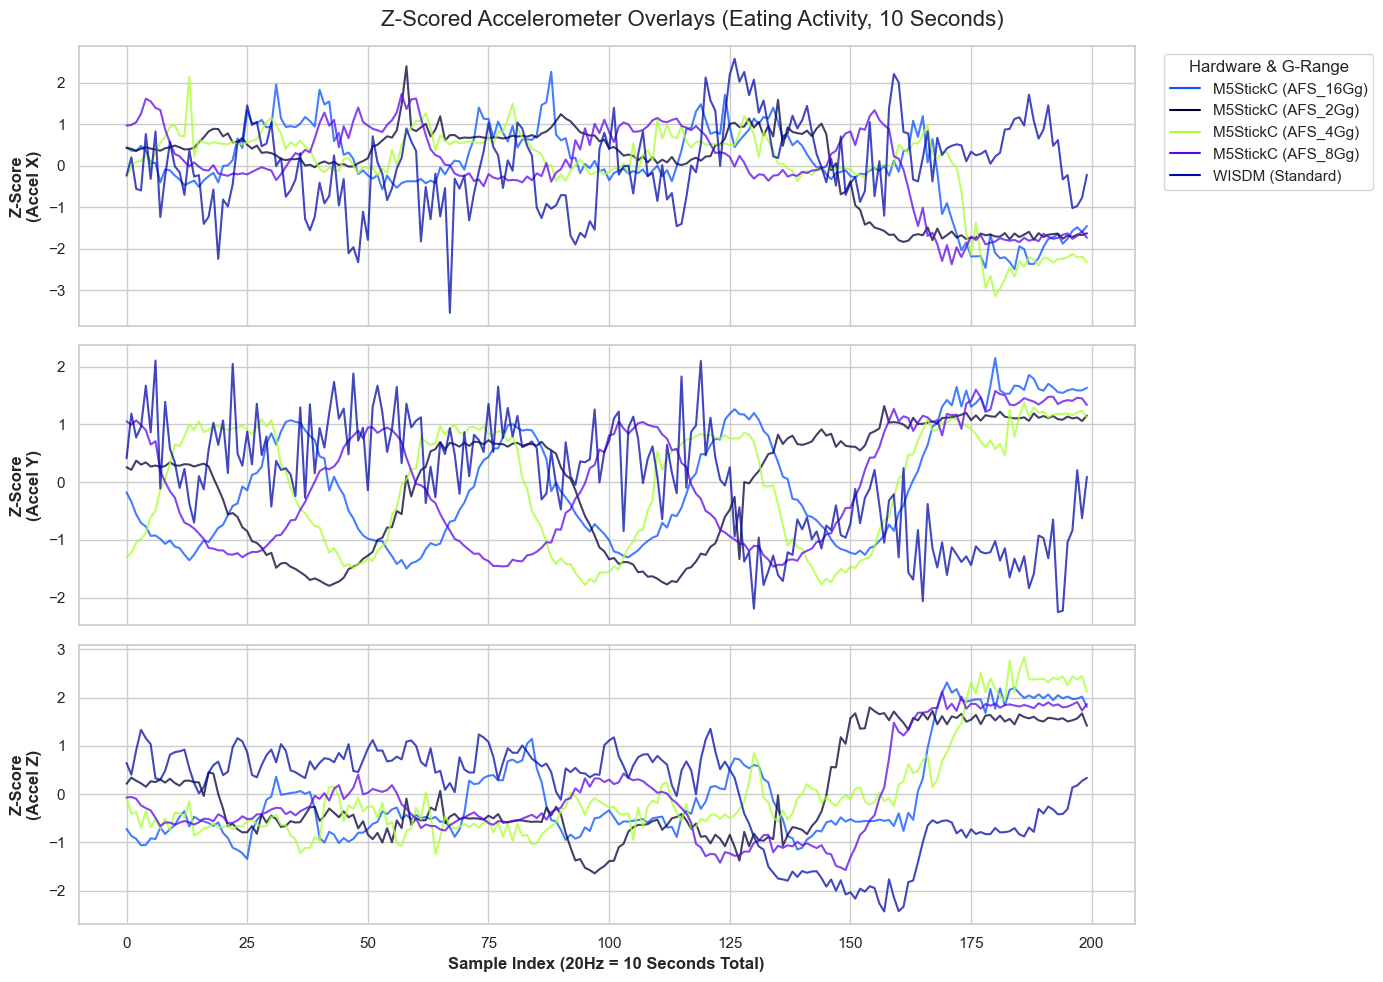

In [11]:
# ==========================================
# 3. Plotting
# ==========================================
sns.set_theme(style="whitegrid")
my_custom_colors = [
    "#0652ff",  # (AFS_16Gg)
    "#020035",  # (AFS_2Gg)
    "#aaff32",  # (AFS_4Gg)
    "#5d06e9",  # (AFS_8Gg)
    "#030aa7"   # WISDM
]
colors = sns.color_palette(my_custom_colors)

# Figure 1: Overlaid Time Series
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig1.suptitle('Z-Scored Accelerometer Overlays (Eating Activity, 10 Seconds)', fontsize=16, y=0.98)

for i, axis in enumerate(['x', 'y', 'z']):
    sns.lineplot(
        data=df_plot, 
        x='sample_idx', 
        y=f'accel_{axis}_z', 
        hue='source', 
        ax=axes1[i],
        palette=colors,
        linewidth=1.5,
        alpha=0.75
    )
    axes1[i].set_ylabel(f'Z-Score\n(Accel {axis.upper()})', fontweight='bold')
    
    if i == 0:
        axes1[i].legend(title='Hardware & G-Range', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        axes1[i].get_legend().remove()

axes1[-1].set_xlabel('Sample Index (20Hz = 10 Seconds Total)', fontweight='bold')
plt.tight_layout()
plt.show()

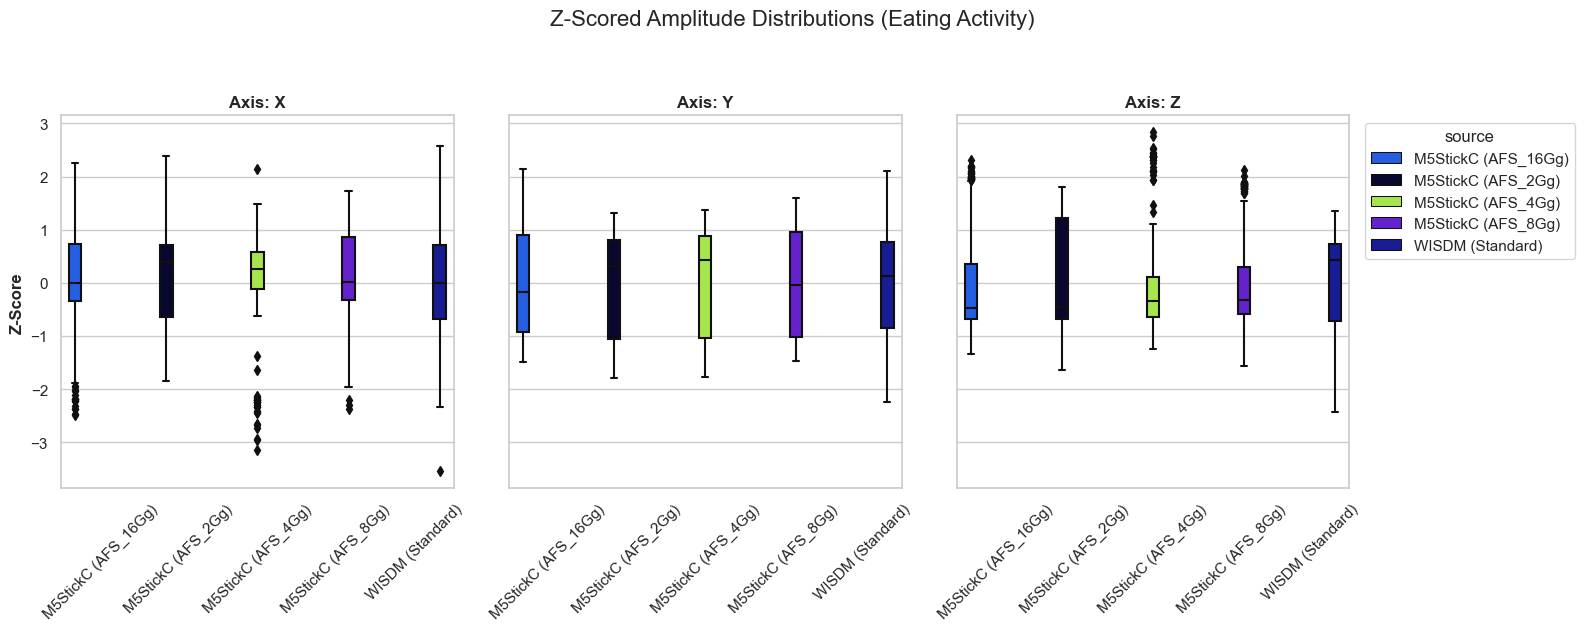

In [12]:
# Figure 2: Distribution Comparison
my_custom_colors = [
    "#0652ff",  # (AFS_16Gg)
    "#020035",  # (AFS_2Gg)
    "#aaff32",  # (AFS_4Gg)
    "#5d06e9",  # (AFS_8Gg)
    "#030aa7"   # WISDM
]
colors = sns.color_palette(my_custom_colors)

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
fig2.suptitle('Z-Scored Amplitude Distributions (Eating Activity)', fontsize=16, y=1.05)

for i, axis in enumerate(['x', 'y', 'z']):
    sns.boxplot(
        data=df_plot, 
        x='source', 
        y=f'accel_{axis}_z', 
        hue='source',
        ax=axes2[i],
        palette=colors,
    )
    
    leg = axes2[i].get_legend()
    if leg is not None:
        if i < 2: 
            leg.remove()
        else:
            sns.move_legend(axes2[i], "upper left", bbox_to_anchor=(1.02, 1))
            
    axes2[i].set_title(f'Axis: {axis.upper()}', fontweight='bold')
    axes2[i].set_xlabel('')
    if i == 0:
        axes2[i].set_ylabel('Z-Score', fontweight='bold')
    else:
        axes2[i].set_ylabel('')
    
    axes2[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()